In [2]:
import pandas as pd
import numpy as np
fov3 = pd.read_parquet("../data/processed/fov3_strips.parquet")
# Get all unique gene targets in the panel
panel_genes = set(fov3['target'].unique())
print(f"Total genes in panel: {len(panel_genes)}")

Total genes in panel: 1123


In [3]:
from liana.resource import select_resource # liana Python package (Dimitrov et al., 2022)

# CellChatDB: curated L-R database (Jin et al., Nat Comms 2021)
# mentioned in connectomeDB2025 - lists LIANA+'s consensus resource as a simple CSV on github (python native)
cellchat_lr = select_resource('CellChatDB')
print(f"CellChatDB: {len(cellchat_lr)} ligand-receptor pairs")
print(f"Unique ligands: {cellchat_lr['ligand'].nunique()}")
print(f"Unique receptors: {cellchat_lr['receptor'].nunique()}")

CellChatDB: 1912 ligand-receptor pairs
Unique ligands: 529
Unique receptors: 490


In [4]:
# Get panel genes
panel_genes = set(fov3['target'].unique())
print(f"Panel genes: {len(panel_genes)}")

# Filter to pairs where BOTH ligand and receptor are in our panel
mask = (cellchat_lr['ligand'].isin(panel_genes) & 
        cellchat_lr['receptor'].isin(panel_genes))
lr_in_panel = cellchat_lr[mask].copy().reset_index(drop=True)

print(f"L-R pairs with both genes in panel: {len(lr_in_panel)}")
print()
print(lr_in_panel.to_string())

Panel genes: 1123
L-R pairs with both genes in panel: 203

       ligand   receptor
0        DLL1     NOTCH1
1        IGF1      IGF1R
2        JAG1     NOTCH1
3      CXCL16      CXCR6
4        IGF2      IGF2R
5       KITLG        KIT
6        IGF2      IGF1R
7       CXCL9      CXCR3
8        CCL5       CCR5
9         EGF       EGFR
10      WNT5A       FZD5
11    TNFSF14       LTBR
12     CD40LG       CD40
13     CXCL10      CXCR3
14       CSF1      CSF1R
15       CSF3      CSF3R
16        HGF        MET
17        TNF   TNFRSF1B
18        INS       INSR
19     TNFSF9    TNFRSF9
20       CD70       CD27
21      FASLG        FAS
22    TNFSF10  TNFRSF10A
23        TNF   TNFRSF1A
24       CD80       CD28
25       CD86       CD28
26       IL1B      IL1R2
27       AREG       EGFR
28       JAG1     NOTCH2
29      WNT5A       FZD4
30       DLL4     NOTCH1
31      PDGFC     PDGFRA
32      PDGFA     PDGFRA
33      PDGFB     PDGFRA
34       FGF1      FGFR1
35       FGF1      FGFR2
36       FGF2   

In [5]:
# Check transcript counts per strip for each gene in our L-R pairs
lr_genes = set(lr_in_panel['ligand']) | set(lr_in_panel['receptor'])

for strip_name in ['strip_2', 'strip_3']:
    strip_df = fov3[fov3['strip'] == strip_name]
    counts = strip_df['target'].value_counts()
    
    print(f"\n{strip_name}:")
    for gene in sorted(lr_genes):
        n = counts.get(gene, 0)
        flag = '  OK' if n >= 50 else '  LOW' if n > 0 else '  ABSENT'
        print(f"  {gene:>12}: {n:>4} transcripts {flag}")


strip_2:
         ACKR1:   20 transcripts   LOW
         ACKR3:   12 transcripts   LOW
         ACKR4:    8 transcripts   LOW
        ADGRE5:   23 transcripts   LOW
        ANGPT1:    7 transcripts   LOW
        ANGPT2:    7 transcripts   LOW
         ANXA1:   34 transcripts   LOW
           APP:   10 transcripts   LOW
          AREG:    7 transcripts   LOW
           AXL:   18 transcripts   LOW
         CCL11:    6 transcripts   LOW
         CCL13:   12 transcripts   LOW
         CCL15:   15 transcripts   LOW
         CCL17:    8 transcripts   LOW
         CCL18:   12 transcripts   LOW
         CCL19:   12 transcripts   LOW
          CCL2:   14 transcripts   LOW
         CCL21:   12 transcripts   LOW
         CCL28:    4 transcripts   LOW
          CCL5:   25 transcripts   LOW
          CCL8:    7 transcripts   LOW
          CCR1:   14 transcripts   LOW
         CCR10:   14 transcripts   LOW
          CCR2:    9 transcripts   LOW
          CCR5:    9 transcripts   LOW
          CCR7:

**Results:**
- Every single L-R pair on CellCHatDB was below the 50 transcript threshold for meaningful K-results
- The counts were majoritively housekeeping genes so it makes sense
- We are only looking at a single strip of a single FOV atm
- 

In [6]:
import spatialdata as sd
sdata_s1 = sd.read_zarr("../data/raw/updated_stitched_S1.zarr")
s1_pts = sdata_s1.points['points'].compute() # lazy Dask to eager Pandas DF

c:\Users\Harry\Desktop\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
c:\Users\Harry\Desktop\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
c:\Users\Harry\Desktop\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
c:\Users\Harry\Desktop\cosmx-pointpattern\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:534: FutureWarning: functools.partial will be a method descriptor in future Python 

In [7]:
print(s1_pts.columns.tolist())
print(s1_pts.head(2))

['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed']
      x    y target cell_ID  z_raw      cell  x_global_px  fov  y_global_px  \
0  4240  301   AKT1       0      7  c_1_10_0        12016   10         8227   
1  4241  479  RPL34       0      7  c_1_10_0        12017   10         8049   

  CellComp  y_global_px_transformed  x_global_px_transformed  
0     <NA>                  12483.0                   4240.0  
1     <NA>                  12305.0                   4241.0  


In [10]:
import matplotlib.pyplot as plt

Found 13 FOVs in S1



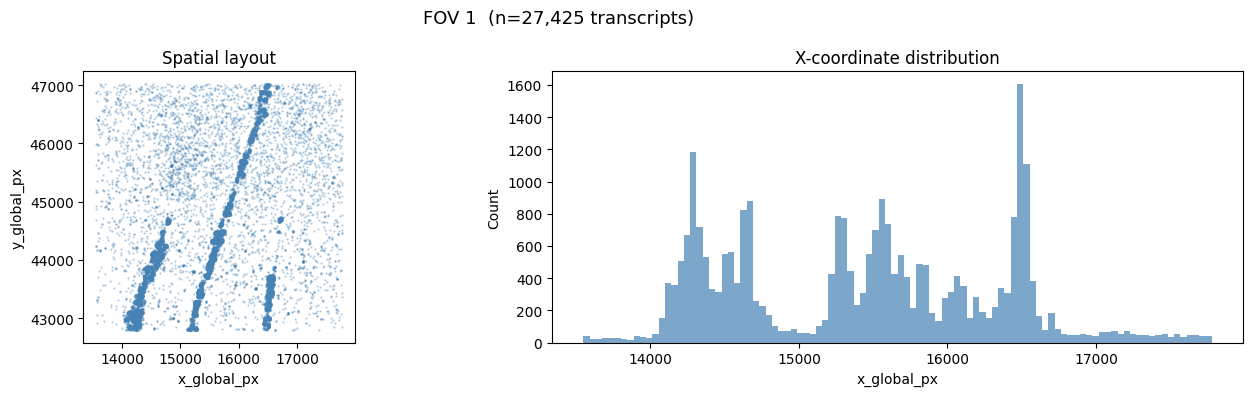

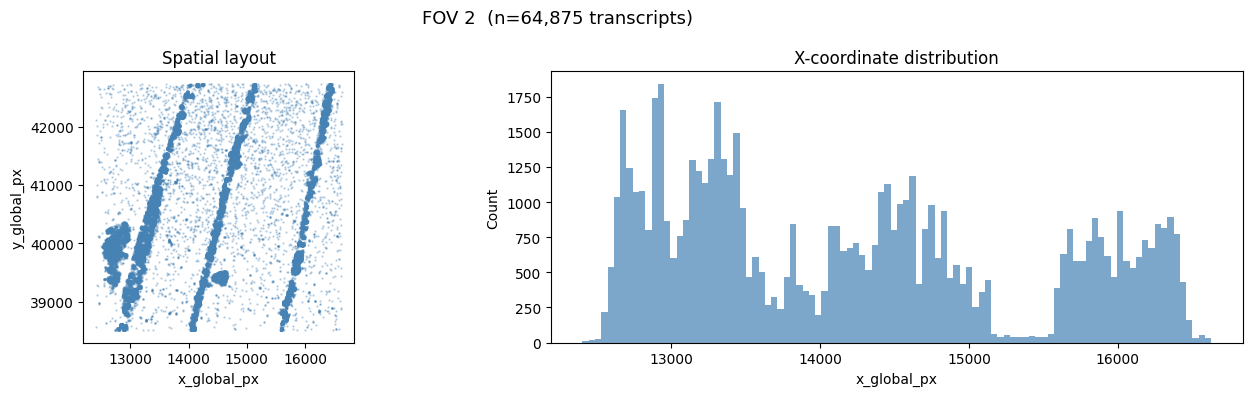

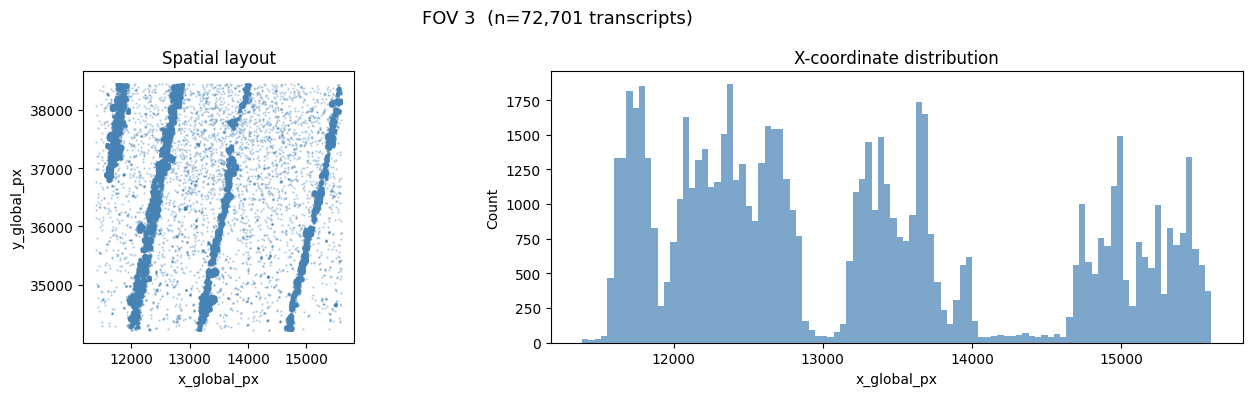

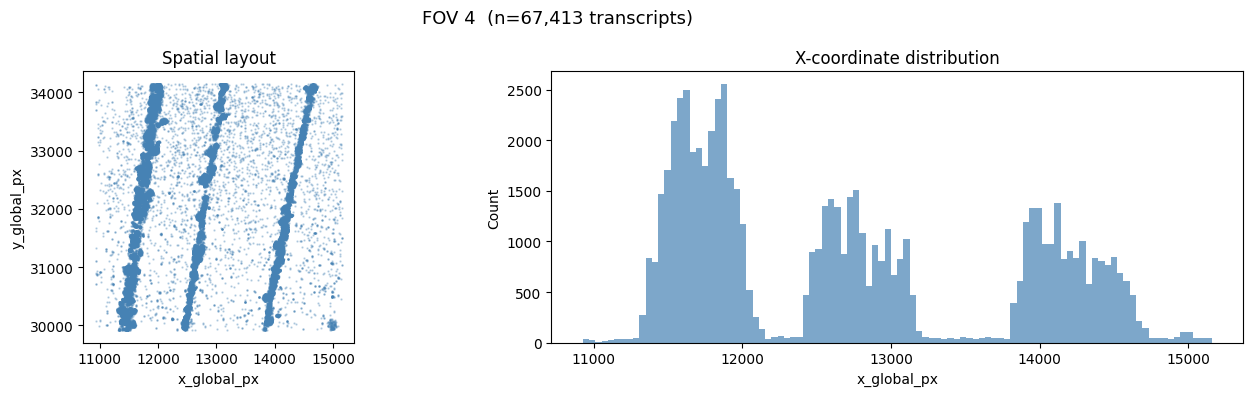

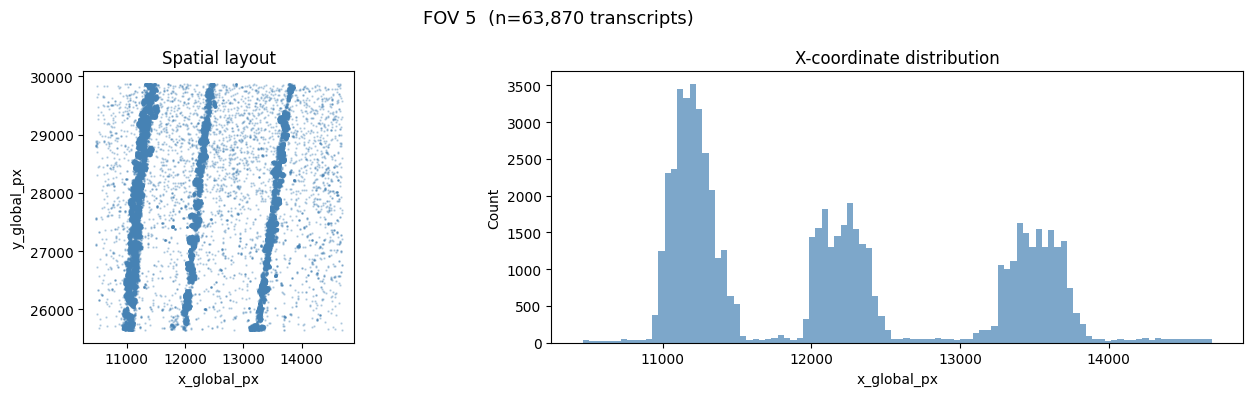

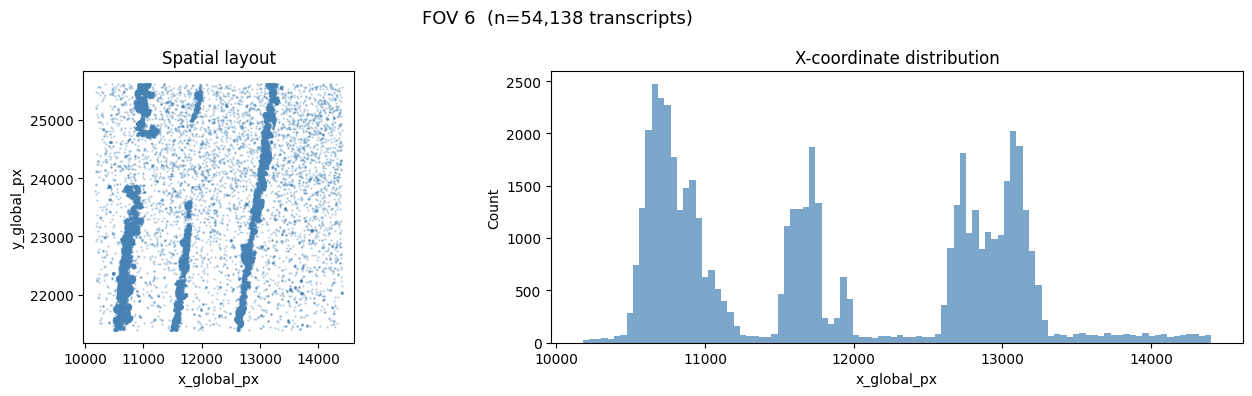

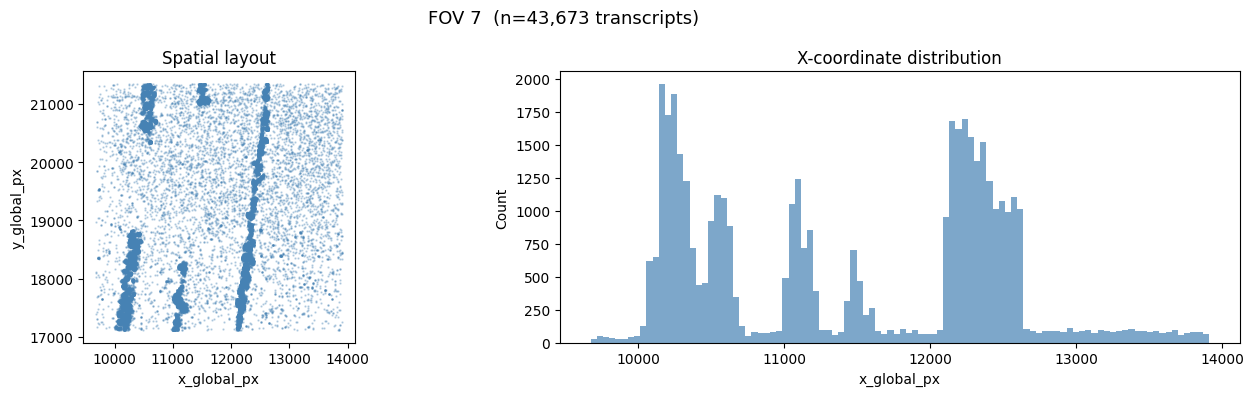

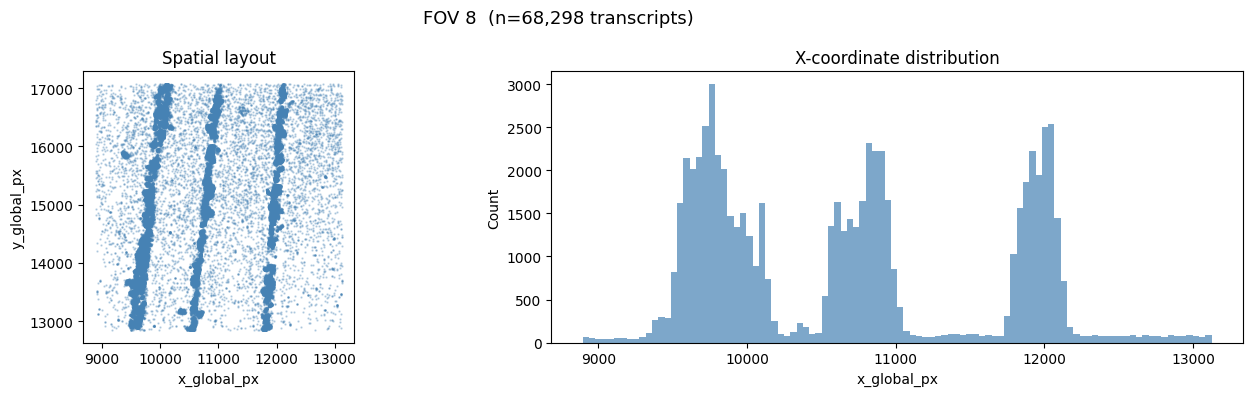

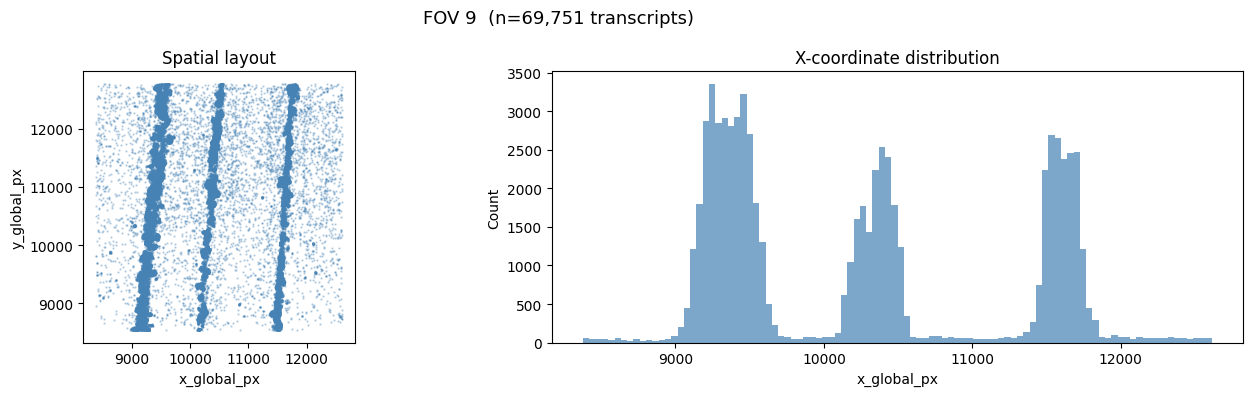

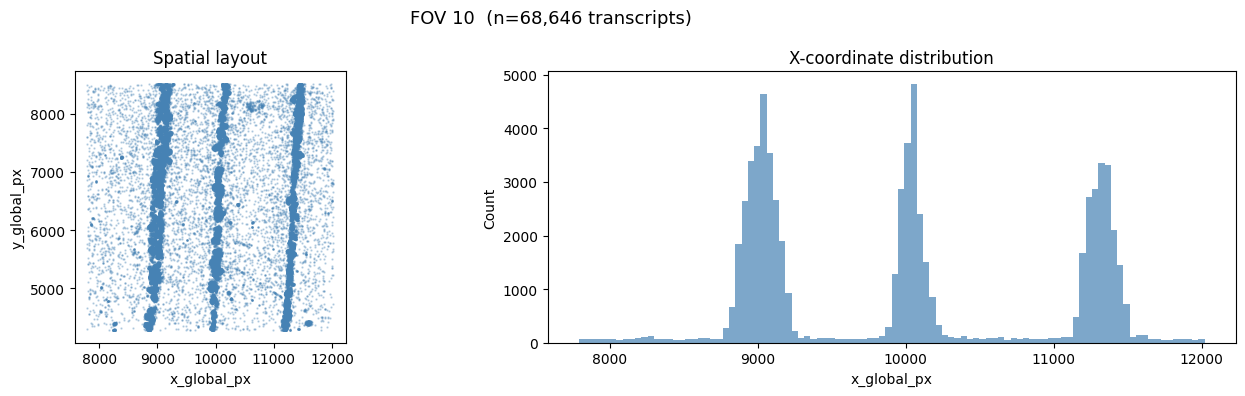

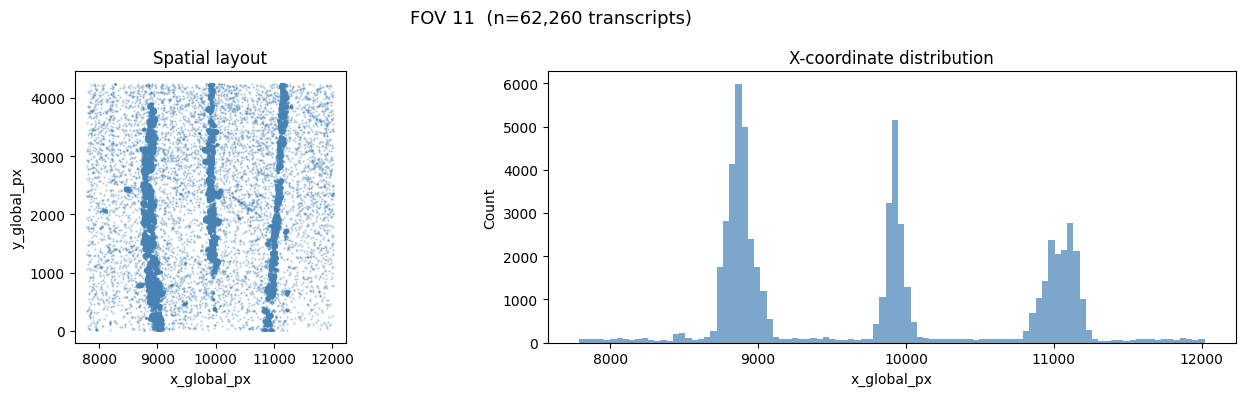

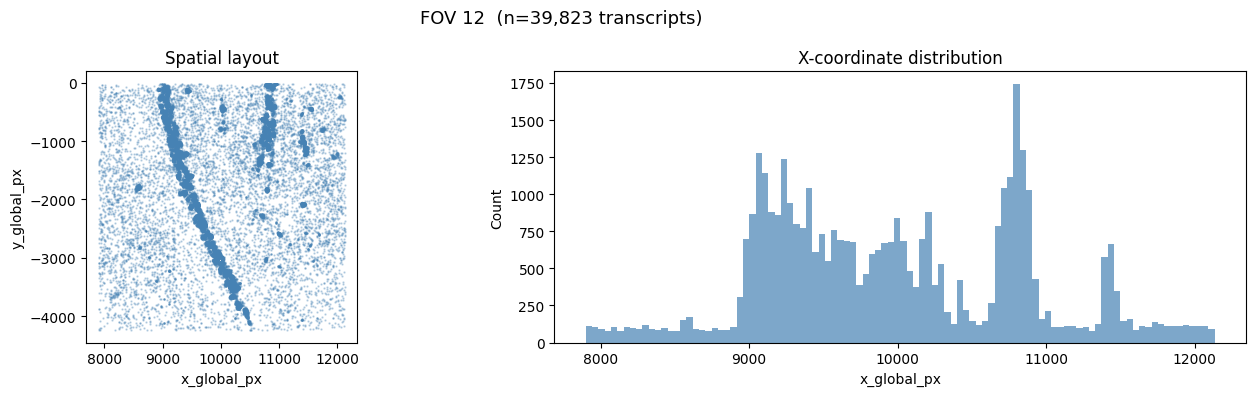

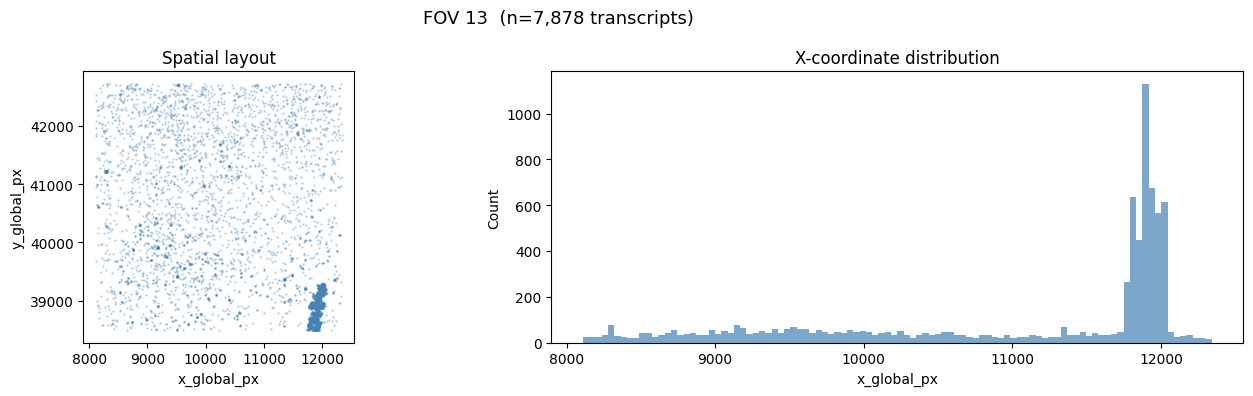

In [11]:
# --- Configuration ---
fov_col = 'fov'
x_col = 'x_global_px'
y_col = 'y_global_px'
seed = 42
fov_ids = sorted(s1_pts[fov_col].unique())

print(f"Found {len(fov_ids)} FOVs in S1\n")

for fov_id in fov_ids:
    fov_df = s1_pts[s1_pts[fov_col] == fov_id]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].scatter(fov_df[x_col], fov_df[y_col],
                    s=0.5, alpha=0.3, color='steelblue')
    axes[0].set_aspect('equal')
    axes[0].set_title(f'Spatial layout')
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)
    
    axes[1].hist(fov_df[x_col], bins=100, color='steelblue', alpha=0.7)
    axes[1].set_title(f'X-coordinate distribution')
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel('Count')
    
    plt.suptitle(f'FOV {fov_id}  (n={len(fov_df):,} transcripts)', fontsize=13)
    plt.tight_layout()
    plt.show()
    print()

In [20]:
fov_config = {
   # 1: {'n_strips': 3, 'keep': [1, 2, 3]},
   # 2: {'n_strips': 3, 'keep': [1, 2, 3]},
   # 3: {'n_strips': 3, 'keep': [1, 2, 3]},
    4: {'n_strips': 3, 'keep': [1, 2, 3]},
    5: {'n_strips': 3, 'keep': [1, 2, 3]},
   # 6: {'n_strips': 3, 'keep': [1, 2, 3]},
   # 7: {'n_strips': 3, 'keep': [1, 2, 3]},
    8: {'n_strips': 3, 'keep': [1, 2, 3]},
    9: {'n_strips': 3, 'keep': [1, 2, 3]},
    10: {'n_strips': 3, 'keep': [1, 2, 3]},
    11: {'n_strips': 3, 'keep': [1, 2, 3]},
   # 12: {'n_strips': 2, 'keep': [1, 3]},
   # 13: {'n_strips': 1, 'keep': [1]}
}

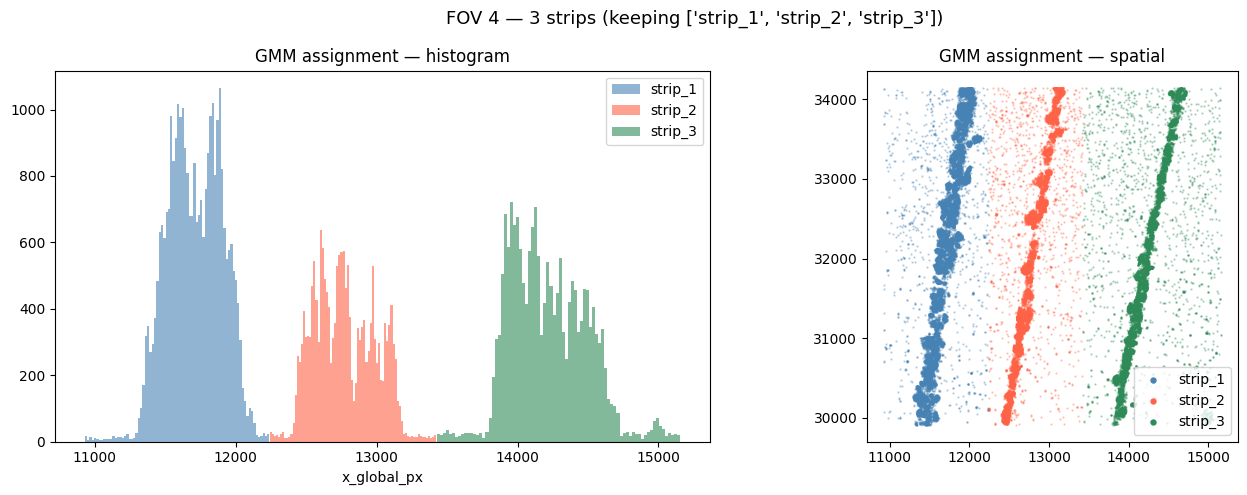

strip
strip_1    30382
strip_2    18333
strip_3    18698



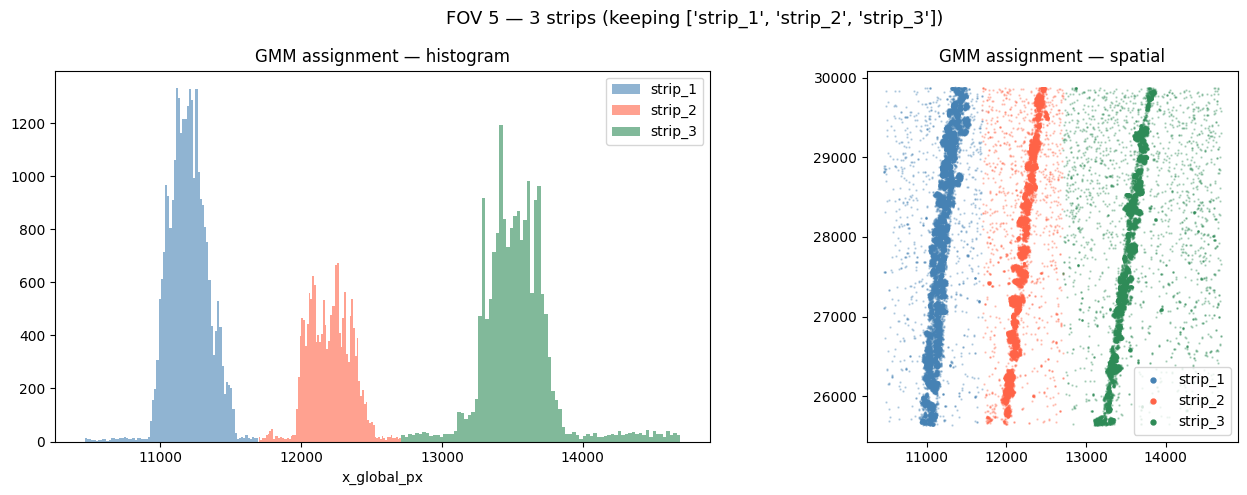

strip
strip_1    28519
strip_2    17265
strip_3    18086



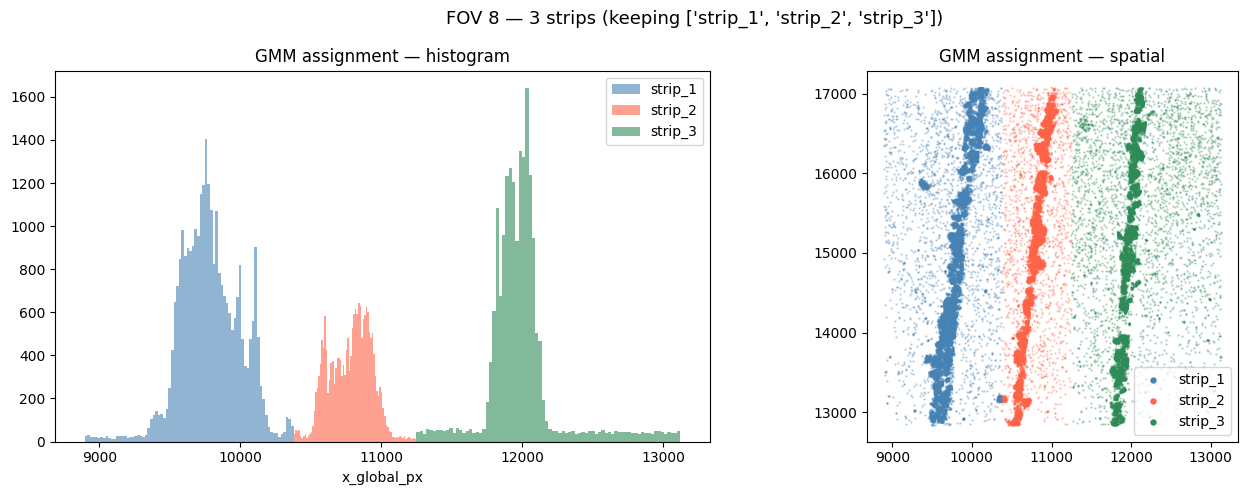

strip
strip_1    29523
strip_2    19707
strip_3    19068



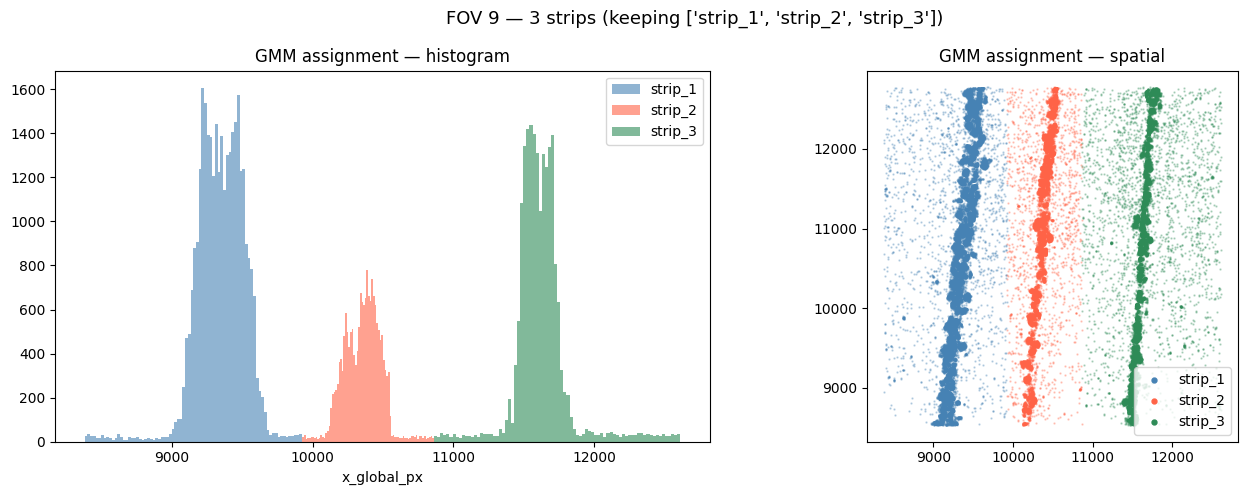

strip
strip_1    32115
strip_2    17864
strip_3    19772



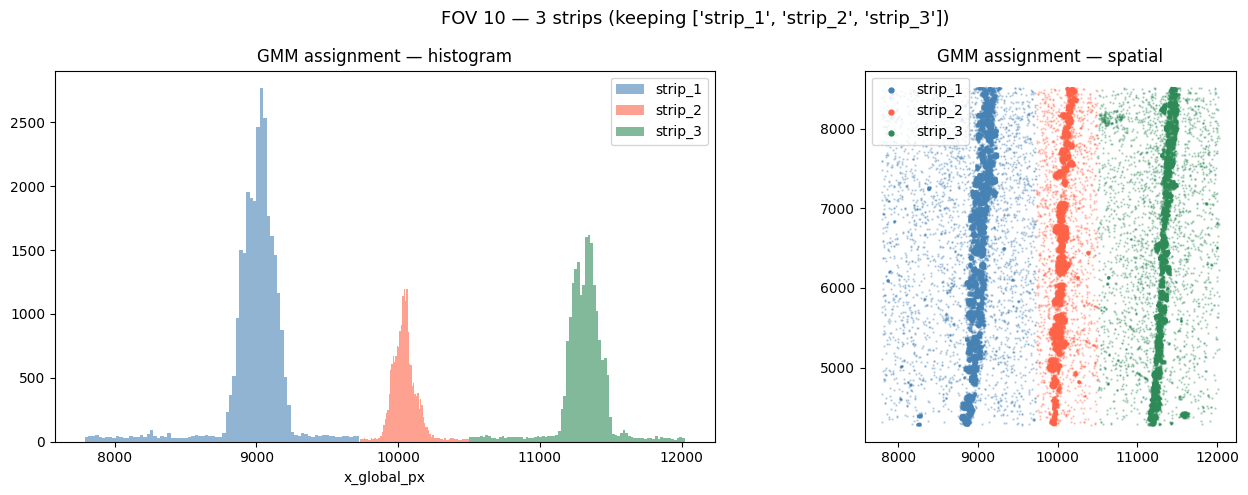

strip
strip_1    28888
strip_2    18931
strip_3    20827



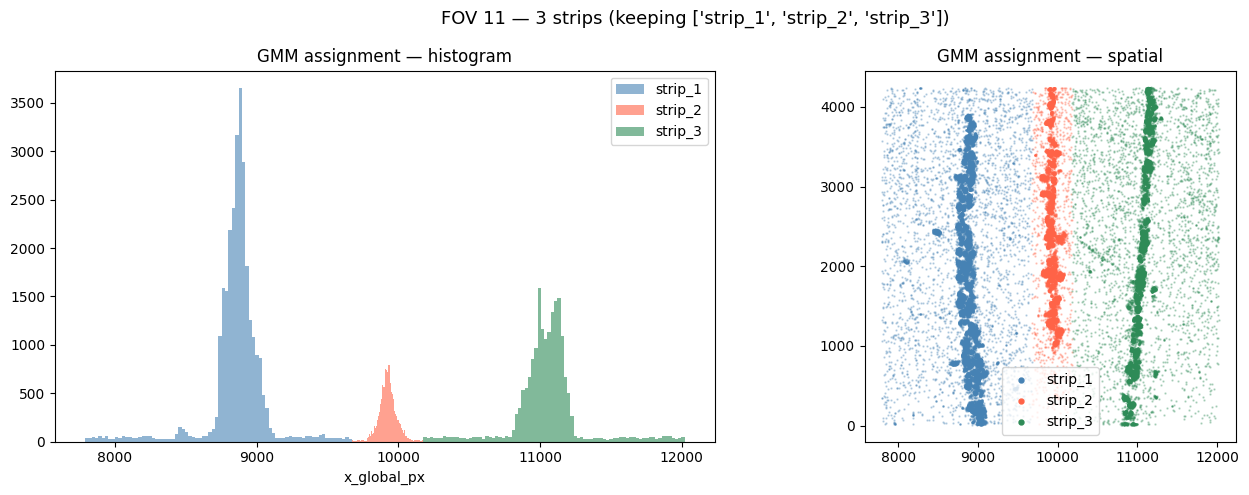

strip
strip_1    28872
strip_2    14829
strip_3    18559


Processed 6 FOVs, 400,238 total transcripts


In [27]:
from sklearn.mixture import GaussianMixture

labelled_fovs = []

for fov_id, config in fov_config.items():
    fov_df = s1_pts[s1_pts[fov_col] == fov_id].copy()
    n_strips = config['n_strips']
    
    # Fit GMM
    X = fov_df[[x_col]].values
    gmm = GaussianMixture(n_components=n_strips, random_state=42)
    gmm.fit(X)
    
    raw_labels = gmm.predict(X)
    
    # Reorder by ascending x: strip_1 = leftmost
    means = gmm.means_.flatten()
    order = np.argsort(means)
    label_map = {old: new for new, old in enumerate(order)}
    ordered_labels = np.array([label_map[l] for l in raw_labels])
    
    fov_df['strip'] = ['strip_' + str(l + 1) for l in ordered_labels]
    
    # Filter to kept strips
    strips_to_keep = [f'strip_{i}' for i in config['keep']]
    fov_df = fov_df[fov_df['strip'].isin(strips_to_keep)].copy()
    
    # Visualise
    colors = {'strip_1': 'steelblue', 'strip_2': 'tomato', 'strip_3': 'seagreen'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for strip_name in sorted(fov_df['strip'].unique()):
        mask = fov_df['strip'] == strip_name
        axes[0].hist(fov_df.loc[mask, x_col], bins=80, alpha=0.6,
                     color=colors[strip_name], label=strip_name)
        axes[1].scatter(fov_df.loc[mask, x_col], fov_df.loc[mask, y_col],
                        s=0.5, alpha=0.3, color=colors[strip_name],
                        label=strip_name)
    
    axes[0].set_title('GMM assignment — histogram')
    axes[0].set_xlabel(x_col)
    axes[0].legend()
    axes[1].set_title('GMM assignment — spatial')
    axes[1].set_aspect('equal')
    axes[1].legend(markerscale=5)
    leg = axes[1].legend(markerscale=5)
    for lh in leg.legend_handles:
        lh.set_alpha(1.0)
    
    plt.suptitle(f'FOV {fov_id} — {n_strips} strips '
                 f'(keeping {strips_to_keep})', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print(fov_df['strip'].value_counts().sort_index().to_string())
    print()
    
    labelled_fovs.append(fov_df)

print(f"\nProcessed {len(labelled_fovs)} FOVs, "
      f"{sum(len(df) for df in labelled_fovs):,} total transcripts")

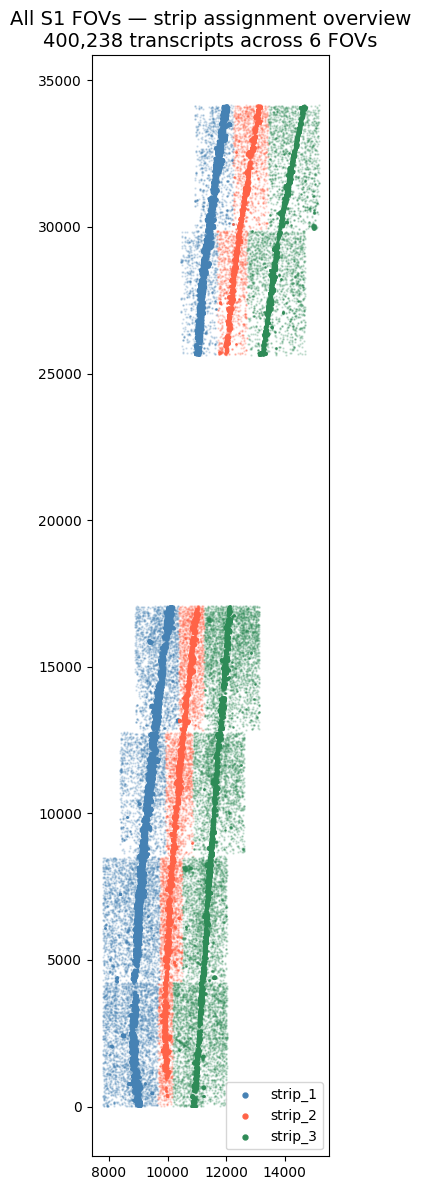

Saved 400,238 transcripts across 6 FOVs


In [33]:
# Combine all labelled FOVs
all_labelled = pd.concat(labelled_fovs, ignore_index=True)

# Overview plot
fig, ax = plt.subplots(figsize=(16, 12))
strip_colors = {'strip_1': 'steelblue', 'strip_2': 'tomato', 'strip_3': 'seagreen'}

for strip_name, color in strip_colors.items():
    mask = all_labelled['strip'] == strip_name
    if mask.any():
        ax.scatter(all_labelled.loc[mask, x_col],
                   all_labelled.loc[mask, y_col],
                   s=0.5, alpha=0.2, color=color, label=strip_name)

ax.set_aspect('equal')
ax.legend(markerscale=10, fontsize=12)
leg = ax.legend(markerscale=5)
for lh in leg.legend_handles:
    lh.set_alpha(1.0)
ax.set_title(f'All S1 FOVs — strip assignment overview\n'
             f'{len(all_labelled):,} transcripts across '
             f'{all_labelled[fov_col].nunique()} FOVs', fontsize=14)
plt.tight_layout()
plt.show()

# Save
all_labelled.attrs = {}
all_labelled.to_parquet('../data/processed/s1_all_strips.parquet', index=False)
print(f"Saved {len(all_labelled):,} transcripts across "
      f"{all_labelled[fov_col].nunique()} FOVs")

In [32]:
print(all_labelled.head())

      x     y  target cell_ID  z_raw     cell  x_global_px  fov  y_global_px  \
0  4239    16   CCRL2       0      7  c_1_4_0        15151    4        34144   
1  4240   173   MS4A1       0      7  c_1_4_0        15152    4        33987   
2  4239   573   LAMA4       0      7  c_1_4_0        15151    4        33587   
3  4239  1220   TGFB1       0      7  c_1_4_0        15151    4        32940   
4  4242  1860  CXCL14       0      7  c_1_4_0        15154    4        32300   

  CellComp  y_global_px_transformed  x_global_px_transformed    strip  
0     <NA>                  38400.0                   7375.0  strip_3  
1     <NA>                  38243.0                   7376.0  strip_3  
2     <NA>                  37843.0                   7375.0  strip_3  
3     <NA>                  37196.0                   7375.0  strip_3  
4     <NA>                  36556.0                   7378.0  strip_3  
